In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
stock = yf.download("AAPL", start="2023-01-01", end="2025-01-01")

# Show first 5 rows
stock.head()

/tmp/ipykernel_24778/137677403.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982712,128.715409,122.097730,128.105761,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700
2023-01-06,127.456749,128.115565,122.805693,123.907004,87754700
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800


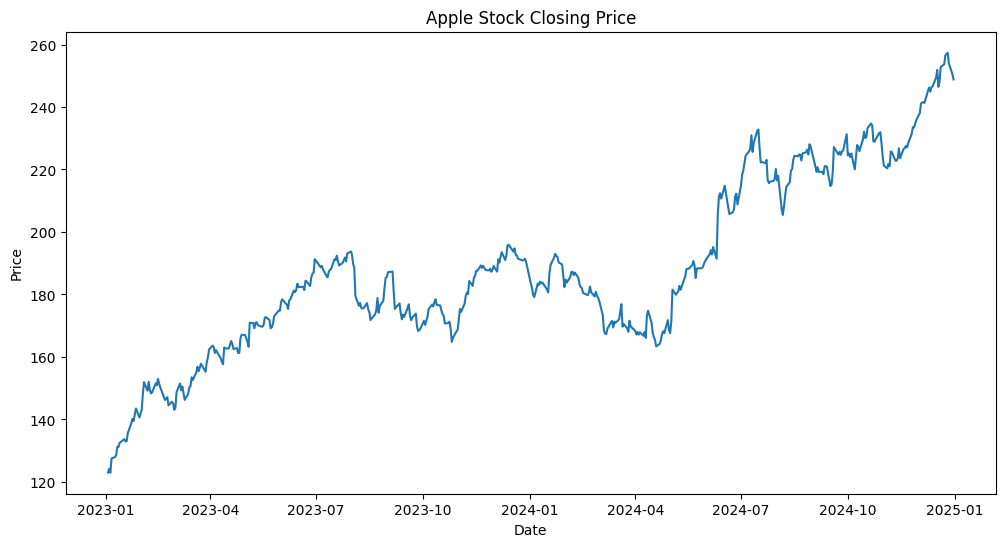

In [3]:
plt.figure(figsize=(12,6))

plt.plot(stock['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [4]:
stock['Daily Return'] = stock['Close'].pct_change()

stock.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2023-01-03,122.982712,128.715409,122.097730,128.105761,112117500,NaN
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600,0.010314
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700,-0.010605
2023-01-06,127.456749,128.115565,122.805693,123.907004,87754700,0.036794
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800,0.004089


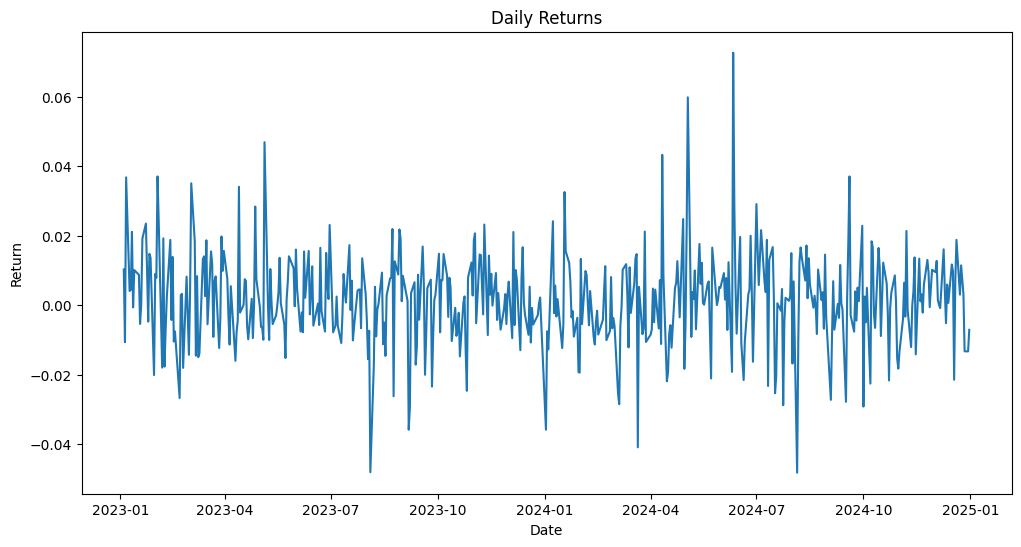

In [5]:
plt.figure(figsize=(12,6))

plt.plot(stock['Daily Return'])

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.show()

In [6]:
volatility = stock['Daily Return'].std()

print("Volatility:", volatility)

Volatility: 0.013451989918676927


In [7]:
# 20-day moving average

stock['MA20'] = stock['Close'].rolling(window=20).mean()

stock.head()

Price,Close,High,Low,Open,Volume,Daily Return,MA20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2023-01-03,122.982712,128.715409,122.097730,128.105761,112117500,NaN,NaN
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600,0.010314,NaN
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700,-0.010605,NaN
2023-01-06,127.456749,128.115565,122.805693,123.907004,87754700,0.036794,NaN
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800,0.004089,NaN


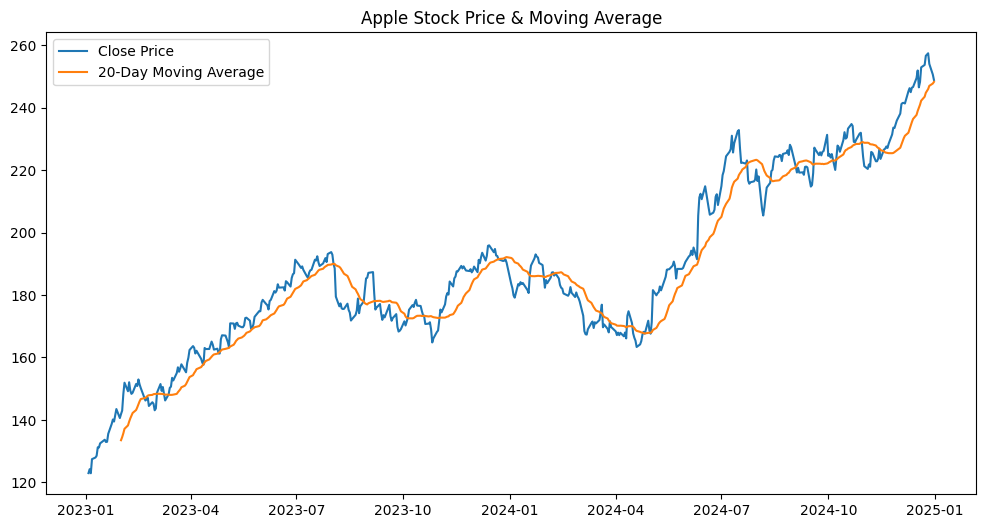

In [8]:
plt.figure(figsize=(12,6))

plt.plot(stock['Close'], label='Close Price')

plt.plot(stock['MA20'], label='20-Day Moving Average')

plt.legend()

plt.title("Apple Stock Price & Moving Average")

plt.show()

In [9]:
stocks = yf.download(
    ['AAPL', 'TSLA', 'NVDA'],
    start='2023-01-01',
    end='2025-01-01'
)['Close']

stocks.head()

/tmp/ipykernel_24778/2235380526.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,NVDA,TSLA
Date,,,
2023-01-03,122.982712,14.299911,108.099998
2023-01-04,124.251190,14.733451,113.639999
2023-01-05,122.933548,14.249964,110.339996
2023-01-06,127.456749,14.843339,113.059998
2023-01-09,127.977913,15.611526,119.769997


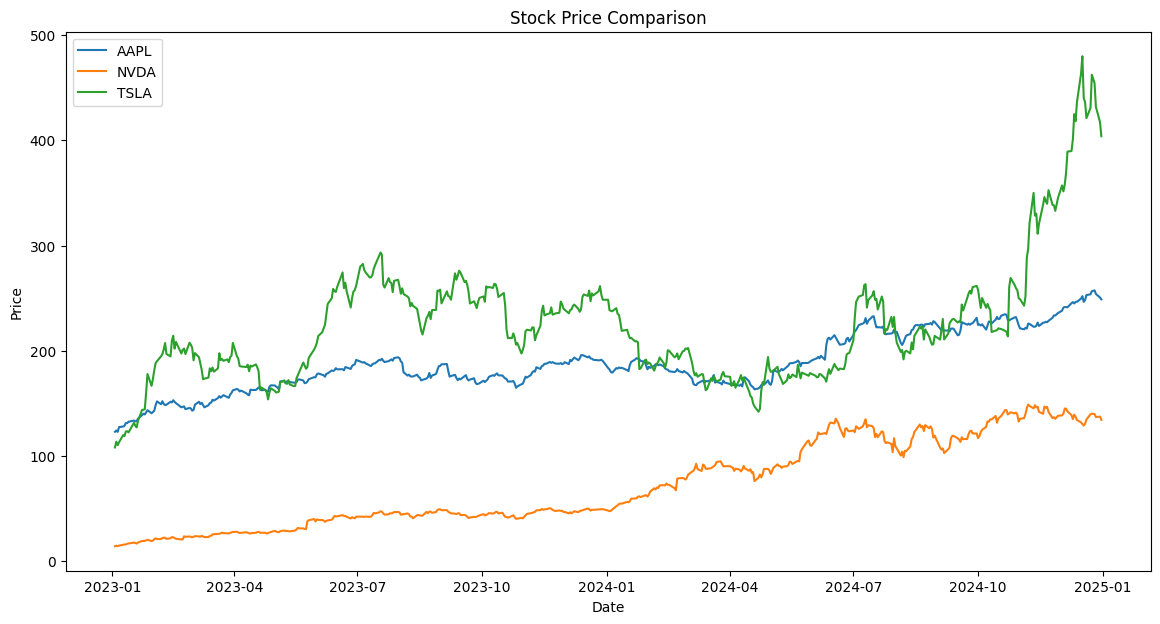

In [10]:
plt.figure(figsize=(14,7))

for company in stocks.columns:
    plt.plot(stocks[company], label=company)

plt.title("Stock Price Comparison")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

In [11]:
normalized = stocks / stocks.iloc[0]

normalized.head()

Ticker,AAPL,NVDA,TSLA
Date,,,
2023-01-03,1.000000,1.000000,1.000000
2023-01-04,1.010314,1.030318,1.051249
2023-01-05,0.999600,0.996507,1.020722
2023-01-06,1.036379,1.038002,1.045883
2023-01-09,1.040617,1.091722,1.107956


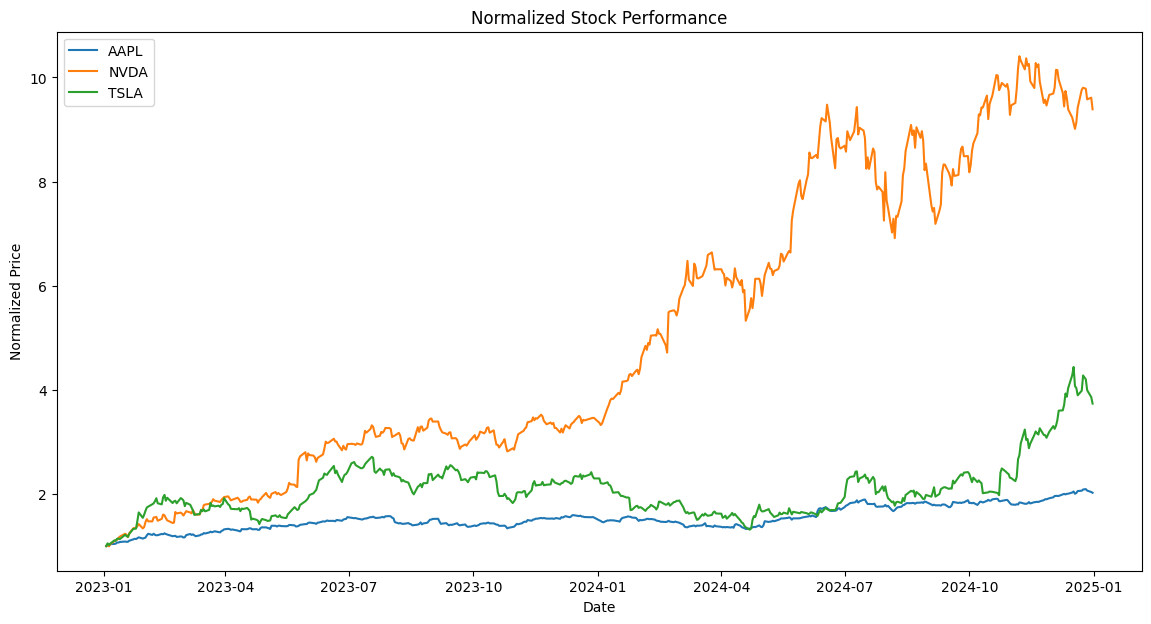

In [12]:

plt.figure(figsize=(14,7))

for company in normalized.columns:
    plt.plot(normalized[company], label=company)

plt.title("Normalized Stock Performance")

plt.xlabel("Date")

plt.ylabel("Normalized Price")

plt.legend()

plt.show()

In [13]:
# Daily returns

returns = stocks.pct_change()

# Correlation matrix

correlation = returns.corr()

correlation

Ticker,AAPL,NVDA,TSLA
Ticker,,,
AAPL,1.000000,0.343259,0.375579
NVDA,0.343259,1.000000,0.298371
TSLA,0.375579,0.298371,1.000000


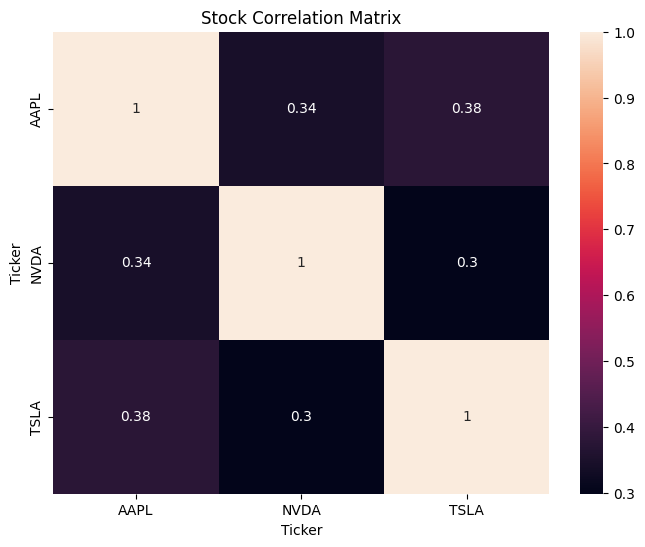

In [14]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title("Stock Correlation Matrix")

plt.show()

In [15]:
print("Best Daily Returns")
print(returns.max())

print("\nWorst Daily Returns")
print(returns.min())

Best Daily Returns
Ticker
AAPL    0.072649
NVDA    0.243697
TSLA    0.219190
dtype: float64

Worst Daily Returns
Ticker
AAPL   -0.048167
NVDA   -0.100046
TSLA   -0.123346
dtype: float64


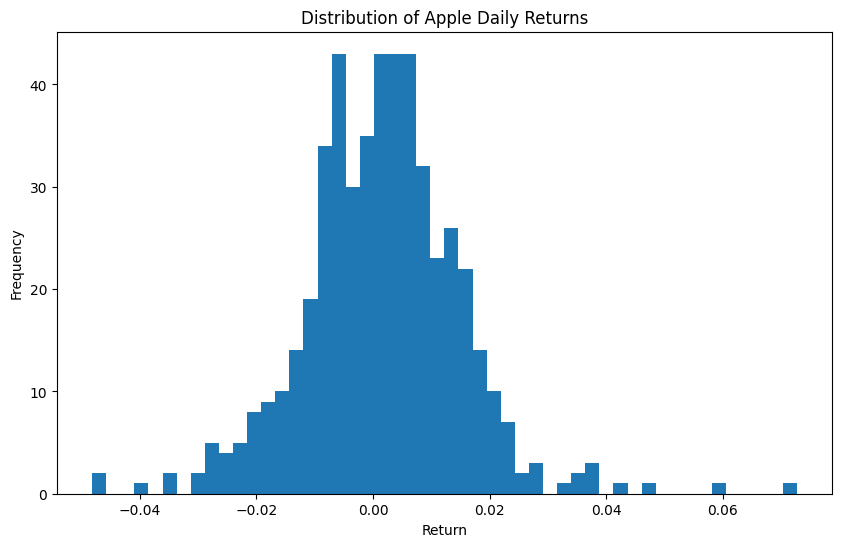

In [16]:
# Histogram of Apple returns

plt.figure(figsize=(10,6))

plt.hist(returns['AAPL'].dropna(), bins=50)

plt.title("Distribution of Apple Daily Returns")

plt.xlabel("Return")

plt.ylabel("Frequency")

plt.show()

# Stock Market Analysis

## Importing Libraries

## Downloading Data

## Visualizing Stock Prices

## Return Analysis

## Volatility Analysis

## Correlation Analysis